In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting


Loaded points: (76, 2)
Loaded losses: (75,)


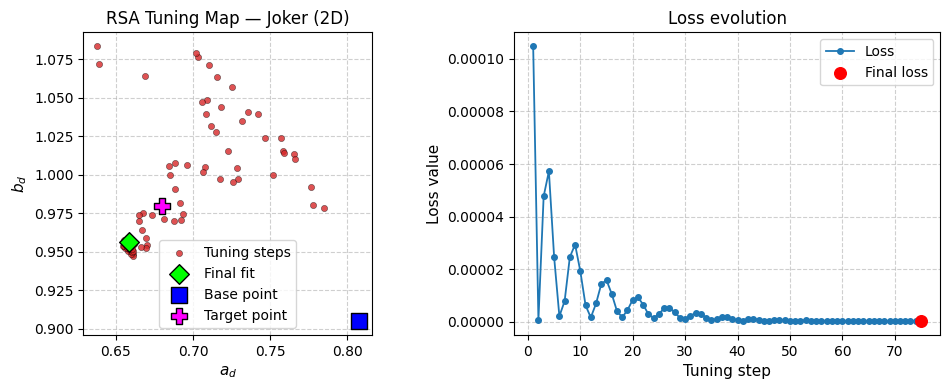

✅ Plot saved to: /pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/2D/plots/Joker_tuning_map_5.png


In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1️⃣ Configuration
# =========================
observable = 'Joker'   # which observable you're plotting
run_nm     = '5'       # which run index (corresponds to file suffix)

plot_configs = {
    'Joker': {
        '1': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/2D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'title':  'RSA Tuning Map — Joker (2D)',
            'color':  'tab:red',
            'marker': 'o',
            'size':   50,
            # Base and target points (optional)
            'base_point':   (0.68 + 0.1275, 0.905),   # Example
            'target_point': (0.68, 0.98),   # Example
        },
        '2': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/2D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'title':  'RSA Tuning Map — Joker (2D)',
            'color':  'tab:red',
            'marker': 'o',
            'size':   50,
            # Base and target points (optional)
            'base_point':   (0.68 + 0.1275, 0.905),   # Example
            'target_point': (0.68, 0.98),   # Example
        },
        '3': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/2D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'title':  'RSA Tuning Map — Joker (2D)',
            'color':  'tab:red',
            'marker': 'o',
            'size':   50,
            # Base and target points (optional)
            'base_point':   (0.68 + 0.1275, 0.905),   # Example
            'target_point': (0.68, 0.98),   # Example
        },
        '4': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/2D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'title':  'RSA Tuning Map — Joker (2D)',
            'color':  'tab:red',
            'marker': 'o',
            'size':   20,
            # Base and target points (optional)
            'base_point':   (0.68 + 0.1275, 0.905),   # Example
            'target_point': (0.68, 0.98),   # Example
        },
        '5': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/2D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'title':  'RSA Tuning Map — Joker (2D)',
            'color':  'tab:red',
            'marker': 'o',
            'size':   20,
            # Base and target points (optional)
            'base_point':   (0.68 + 0.1275, 0.905),   # Example
            'target_point': (0.68, 0.98),   # Example
        },
        '6': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/2D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'title':  'RSA Tuning Map — Joker (2D)',
            'color':  'tab:red',
            'marker': 'o',
            'size':   20,
            # Base and target points (optional)
            'base_point':   (0.68 + 0.1275, 0.905),   # Example
            'target_point': (0.68, 0.98),   # Example
        },
    },
}

def get_config(obs: str, run: str):
    try:
        return plot_configs[obs][run]
    except KeyError:
        raise ValueError(f"No config found for observable='{obs}', run='{run}'")

config = get_config(observable, run_nm)
data_folder = config['data_folder']
save_nm = run_nm

# =========================
# 2️⃣ Load data
# =========================
points = np.load(os.path.join(data_folder, f'all_params_{save_nm}.npy'))
loss_values = np.load(os.path.join(data_folder, f'loss_values_{save_nm}.npy'))

print("Loaded points:", points.shape)
print("Loaded losses:", loss_values.shape)

x, y = points[:, 0], points[:, 1]
xf, yf = x[-1], y[-1]

# =========================
# 3️⃣ Setup figure
# =========================
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# ---- Left: parameter trajectory ----
ax = axs[0]
ax.scatter(
    x, y,
    c=config['color'],
    marker=config['marker'],
    s=config['size'],
    alpha=0.8,
    edgecolors='k',
    linewidths=0.3,
    label='Tuning steps',
    zorder=2
)

# Final fitted point
ax.scatter(xf, yf, c='lime', edgecolors='black', s=100, marker='D', label='Final fit', zorder=4)

# Base and target points (if defined)
if 'base_point' in config:
    bx, by = config['base_point']
    ax.scatter(bx, by, c='blue', marker='s', s=120, edgecolors='k', label='Base point', zorder=5)

if 'target_point' in config:
    tx, ty = config['target_point']
    ax.scatter(tx, ty, c='magenta', marker='P', s=120, edgecolors='k', label='Target point', zorder=6)

ax.set_title(config['title'], fontsize=12, weight='bold')
ax.set_xlabel(config['xlabel'], fontsize=11)
ax.set_ylabel(config['ylabel'], fontsize=11)
ax.legend(frameon=True, loc='best')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_aspect('equal', adjustable='box')

# ---- Right: loss evolution ----
ax2 = axs[1]
steps = np.arange(1, len(loss_values) + 1)
ax2.plot(steps, loss_values, '-o', color='tab:blue', markersize=4, linewidth=1.3, label='Loss')

# Mark final loss point
ax2.scatter(steps[-1], loss_values[-1], c='red', s=70, zorder=3, label='Final loss')

ax2.set_xlabel('Tuning step', fontsize=11)
ax2.set_ylabel('Loss value', fontsize=11)
ax2.set_title('Loss evolution', fontsize=12, weight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(frameon=True)

# =========================
# 4️⃣ Save and show
# =========================
plt.tight_layout()
out_dir = os.path.join(data_folder, 'plots')
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f'{observable}_tuning_map_{run_nm}.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: {out_path}")


3D PLOTS

Loaded points: (76, 3)
Loaded losses: (75,)


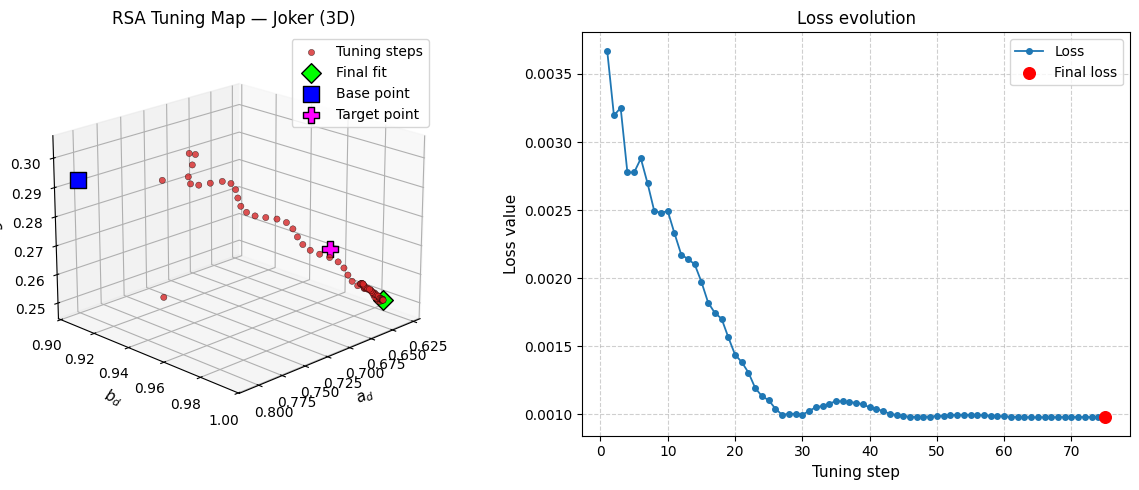

✅ Plot saved to: /pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/3D/plots/Joker_tuning_map_3_3D.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plots

# =========================
# 1️⃣ Configuration
# =========================
observable = 'Joker'   # which observable you're plotting
run_nm     = '3'       # which run index (corresponds to file suffix)

plot_configs = {
    'Joker': {
        '1': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/3D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'zlabel': r'$\sigma$',
            'title':  'RSA Tuning Map — Joker (3D)',
            'color':  'tab:red',
            'marker': 'o-',
            'size':   20,
            'base_point':   (0.68 + 0.1275, 0.905, 0.2925),   # Example 3D point
            'target_point': (0.68, 0.98, 0.27125),            # Example 3D point
        },
        '2': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/3D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'zlabel': r'$\sigma$',
            'title':  'RSA Tuning Map — Joker (3D)',
            'color':  'tab:red',
            'marker': 'o',
            'size':   20,
            'base_point':   (0.68 + 0.1275, 0.905, 0.2925),   # Example 3D point
            'target_point': (0.68, 0.98, 0.27125),            # Example 3D point
        },
        '3': {
            'data_folder': '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tune_map/Joker/3D/',
            'xlabel': r'$a_d$',
            'ylabel': r'$b_d$',
            'zlabel': r'$\sigma$',
            'title':  'RSA Tuning Map — Joker (3D)',
            'color':  'tab:red',
            'marker': 'o',
            'size':   20,
            'base_point':   (0.68 + 0.1275, 0.905, 0.2925),   # Example 3D point
            'target_point': (0.68, 0.98, 0.27125),            # Example 3D point
        },
    },
}

def get_config(obs: str, run: str):
    try:
        return plot_configs[obs][run]
    except KeyError:
        raise ValueError(f"No config found for observable='{obs}', run='{run}'")

config = get_config(observable, run_nm)
data_folder = config['data_folder']
save_nm = run_nm

# =========================
# 2️⃣ Load data
# =========================
points = np.load(os.path.join(data_folder, f'all_params_{save_nm}.npy'))
loss_values = np.load(os.path.join(data_folder, f'loss_values_{save_nm}.npy'))

print("Loaded points:", points.shape)
print("Loaded losses:", loss_values.shape)

x, y, z = points[:, 0], points[:, 1], points[:, 2]
xf, yf, zf = x[-1], y[-1], z[-1]

# =========================
# 3️⃣ Setup figure
# =========================
fig = plt.figure(figsize=(12, 5))

# ---- Left: 3D parameter trajectory ----
ax = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax.scatter(
    x, y, z,
    c=config['color'],
    marker=config['marker'],
    s=config['size'],
    alpha=0.8,
    edgecolors='k',
    linewidths=0.3,
    label='Tuning steps',
    zorder=2
)

# Final fitted point
ax.scatter(xf, yf, zf, c='lime', edgecolors='black', s=100, marker='D', label='Final fit', zorder=4)

# Base and target points (if defined)
if 'base_point' in config:
    bx, by, bz = config['base_point']
    ax.scatter(bx, by, bz, c='blue', marker='s', s=120, edgecolors='k', label='Base point', zorder=5)

if 'target_point' in config:
    tx, ty, tz = config['target_point']
    ax.scatter(tx, ty, tz, c='magenta', marker='P', s=120, edgecolors='k', label='Target point', zorder=6)

ax.set_title(config['title'], fontsize=12, weight='bold')
ax.set_xlabel(config['xlabel'], fontsize=11)
ax.set_ylabel(config['ylabel'], fontsize=11)
ax.set_zlabel(config['zlabel'], fontsize=11)
ax.legend(frameon=True, loc='best')
ax.view_init(elev=20, azim=45) 
ax.grid(True, linestyle='--', alpha=0.6)

# ---- Right: loss evolution ----
ax2 = fig.add_subplot(1, 2, 2)
steps = np.arange(1, len(loss_values) + 1)
ax2.plot(steps, loss_values, '-o', color='tab:blue', markersize=4, linewidth=1.3, label='Loss')

# Mark final loss point
ax2.scatter(steps[-1], loss_values[-1], c='red', s=70, zorder=3, label='Final loss')

ax2.set_xlabel('Tuning step', fontsize=11)
ax2.set_ylabel('Loss value', fontsize=11)
ax2.set_title('Loss evolution', fontsize=12, weight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(frameon=True)

# =========================
# 4️⃣ Save and show
# =========================
plt.tight_layout()
out_dir = os.path.join(data_folder, 'plots')
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f'{observable}_tuning_map_{run_nm}_3D.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved to: {out_path}")
